# Notebook 10 — Evaluate Two Models

## Purpose
This notebook performs the **final independent evaluation** of the trained  
classifiers for the DIP-based AI image detection pipeline using the normalized  
**25-dimensional Digital Image Processing (DIP) feature vectors**.

The notebook evaluates the two trained models:

- RBF Support Vector Machine (RBF SVM)  
- Multi-Layer Perceptron (MLP)  

Both models are applied to the **held-out test dataset**, which has not been  
used during training or validation, ensuring an unbiased assessment of model  
performance.

---

## Inputs
This notebook uses the following inputs:

- Normalized test dataset:
  - `metadata/vectors/test_feature_vectors_normalized.csv`

- Trained model files:
  - `metadata/models/final_rbf_svm_model.pkl`
  - `metadata/models/final_mlp_model.pkl`

- Project configuration file:
  - `project_config.py`

---

## Local Execution Assumptions
This notebook is designed to run within the **local GitHub project structure**  
or a compatible environment such as Google Colab.

It assumes:

- the project repository is available locally or cloned at runtime  
- `src/project_config.py` is accessible  
- prior notebooks have generated the required model and dataset files  
- required Python packages (NumPy, pandas, scikit-learn) are installed  

---

## Important Note
The test dataset is **completely independent** of the training data and must  
not be used for model selection or tuning.

All preprocessing and normalization have already been performed in prior  
notebooks.

All evaluation metrics are computed using the **AI class as the positive class**.

---

## Process Overview
This notebook evaluates both trained models on the held-out test dataset.  
The workflow includes:

1. loading and validating the normalized test dataset  
2. preparing feature and label arrays  
3. loading trained models  
4. generating predictions and class probabilities  
5. computing performance metrics  
6. generating confusion matrices  
7. computing ROC curves  
8. comparing final model performance  
9. saving evaluation outputs  

---

## Outputs
All outputs are saved to `metadata/results/`:

- `final_test_results.csv`
- `final_test_results.json`
- `final_confusion_matrix_mlp.csv`
- `final_confusion_matrix_rbf_svm.csv`
- `final_roc_points_mlp.csv`
- `final_roc_points_rbf_svm.csv`
- `final_comparison_summary.csv`

---

## Key Design Choice
This notebook evaluates **both trained classifiers** rather than selecting  
a single “best” model beforehand.

This enables:

- direct comparison on identical test data  
- more robust interpretation of model behavior  
- stronger experimental conclusions  

---

## Scope Limitation
This notebook does **not** perform:

- model training  
- cross-validation  
- hyperparameter tuning  

These steps are handled in earlier notebooks.

---

## Cell-by-Cell Structure

### Cell 1
Import required libraries.

### Cell 2
Load the normalized test dataset.

### Cell 3
Validate dataset and prepare `X_test` and `y_test`.

### Cell 4
Load trained models.

### Cell 5
Generate predictions and probabilities.

### Cell 6
Compute evaluation metrics.

### Cell 7
Generate confusion matrices.

### Cell 8
Compute ROC curves.

### Cell 9
Build final comparison summary.

### Cell 10
Save evaluation outputs.

In [1]:
# ============================================================
# Startup (Environment + Path Setup + Verification)
# ============================================================

import os
import sys
from pathlib import Path

# ------------------------------------------------------------
# Clone repo into Colab runtime (if needed)
# ------------------------------------------------------------
REPO_URL = "https://github.com/pgailinas/dip-ai-image-detection.git"
REPO_DIR = Path("/content/dip-ai-image-detection")

if not REPO_DIR.exists():
    print("Cloning repository...")
    os.system(f"git clone {REPO_URL} {REPO_DIR}")

# ------------------------------------------------------------
# Make src/ importable
# ------------------------------------------------------------
SRC_DIR = REPO_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# ------------------------------------------------------------
# Import shared configuration
# ------------------------------------------------------------
from project_config import (
    TEST_NORMALIZED_FILENAME,
    NUM_FEATURES,
    METADATA_COLUMNS,
    AI_LABEL,
    REAL_LABEL,
)

# ------------------------------------------------------------
# Define paths
# ------------------------------------------------------------
METADATA_ROOT = REPO_DIR / "metadata"
VECTORS_DIR = METADATA_ROOT / "vectors"
MODELS_DIR = METADATA_ROOT / "models"
RESULTS_DIR = METADATA_ROOT / "results"

RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Define input paths
# ------------------------------------------------------------
TEST_FEATURE_VECTORS_NORMALIZED_CSV = VECTORS_DIR / TEST_NORMALIZED_FILENAME

MLP_MODEL_PATH = MODELS_DIR / "final_mlp_model.pkl"
RBF_MODEL_PATH = MODELS_DIR / "final_rbf_svm_model.pkl"

# ------------------------------------------------------------
# Define output paths
# ------------------------------------------------------------
FINAL_RESULTS_CSV_PATH = RESULTS_DIR / "final_test_results.csv"
FINAL_RESULTS_JSON_PATH = RESULTS_DIR / "final_test_results.json"

CONFUSION_MATRIX_MLP_PATH = RESULTS_DIR / "final_confusion_matrix_mlp.csv"
CONFUSION_MATRIX_RBF_PATH = RESULTS_DIR / "final_confusion_matrix_rbf_svm.csv"

ROC_POINTS_MLP_PATH = RESULTS_DIR / "final_roc_points_mlp.csv"
ROC_POINTS_RBF_PATH = RESULTS_DIR / "final_roc_points_rbf_svm.csv"

FINAL_COMPARISON_PATH = RESULTS_DIR / "final_comparison_summary.csv"

# ------------------------------------------------------------
# Verify required files
# ------------------------------------------------------------
print("Verifying required input files...\n")

required_files = [
    TEST_FEATURE_VECTORS_NORMALIZED_CSV,
    MLP_MODEL_PATH,
    RBF_MODEL_PATH
]

missing = [str(f) for f in required_files if not f.exists()]

if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

print("All required input files are present.")



Cloning repository...
Verifying required input files...

All required input files are present.


In [14]:
# ============================================================
# Cell 1: Import Required Libraries
# ============================================================

import numpy as np
import pandas as pd
import pickle

import matplotlib.pyplot as plt
import seaborn as sns
import json

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)

from sklearn.preprocessing import LabelEncoder



In [3]:
# ============================================================
# Cell 2: Load Normalized Test Data
# ============================================================

print("Loading normalized test dataset...\n")

# ------------------------------------------------------------
# Load CSV
# ------------------------------------------------------------
df_test = pd.read_csv(TEST_FEATURE_VECTORS_NORMALIZED_CSV)

# ------------------------------------------------------------
# Display basic dataset information
# ------------------------------------------------------------
print("Test dataset loaded successfully.\n")

print("Shape:")
print(df_test.shape)

print("\nColumn names:")
for col in df_test.columns:
    print(col)

# ------------------------------------------------------------
# Preview first few rows
# ------------------------------------------------------------
print("\nFirst 5 rows:")
display(df_test.head())



Loading normalized test dataset...

Test dataset loaded successfully.

Shape:
(3600, 29)

Column names:
filename
class_label
source_dataset
subset
Mean Gradient
Std Gradient
Max Gradient
Gradient Entropy
Edge Density
Orientation Mean
Orientation Std
Orientation Entropy
Global Entropy
Local Entropy Mean
Local Entropy Std
Intensity Mean
Intensity Std
Laplacian Variance
Patch Variance Mean
Patch Variance Std
Noise Residual Energy
Low Frequency Energy Ratio
High Frequency Energy Ratio
Radial Mean
Radial Std
Radial Entropy
Spectral Centroid
Spectral Bandwidth
Log Spectrum Std

First 5 rows:


,filename,class_label,source_dataset,subset,Mean Gradient,Std Gradient,Max Gradient,Gradient Entropy,Edge Density,Orientation Mean,...,Patch Variance Std,Noise Residual Energy,Low Frequency Energy Ratio,High Frequency Energy Ratio,Radial Mean,Radial Std,Radial Entropy,Spectral Centroid,Spectral Bandwidth,Log Spectrum Std
0,rl_coco_001786.png,rl,MS_COCO_2017,test,0.497872,-0.409551,0.681864,0.559988,0.054908,-0.305565,...,-0.743924,1.283031,0.072984,-0.000168,-0.175451,-0.167723,-0.549996,-0.387637,-0.204424,-0.898870
1,rl_coco_001292.png,rl,MS_COCO_2017,test,0.927560,0.358681,0.946748,0.880741,0.393183,-0.422829,...,0.317994,1.554584,-0.319957,0.585821,-0.240700,-0.242071,-0.549996,-0.065630,0.382678,-1.479785
2,ai_sdxl_002062.png,ai,SDXL_Generated_10K,test,-0.620579,0.043886,1.061698,-1.269570,-0.505036,-0.727340,...,0.252183,-0.682819,0.625482,-0.583366,0.996778,1.003541,-0.549996,-0.472758,-0.712630,0.485553
3,ai_sdxl_000022.png,ai,SDXL_Generated_10K,test,0.403077,-0.557194,-1.870341,1.648585,1.121353,1.184433,...,-1.132525,0.828271,0.229313,-0.267265,-0.498871,-0.480981,-0.549996,-0.363626,-0.186430,1.645108
4,ai_diff_002198.png,ai,DiffusionDB,test,-0.126248,0.518973,0.726811,-0.540193,-0.054409,1.185280,...,0.585600,0.056304,0.129764,-0.026978,0.060581,0.051685,-0.549996,-0.160865,-0.006949,-1.300368


In [4]:
# ============================================================
# Cell 3: Validate Test Data and Prepare Evaluation Inputs
# ============================================================

print("Validating test dataset and preparing evaluation inputs...\n")

# ------------------------------------------------------------
# Verify required metadata columns
# ------------------------------------------------------------
missing_metadata_cols = [col for col in METADATA_COLUMNS if col not in df_test.columns]

if missing_metadata_cols:
    raise ValueError(f"Missing required metadata columns: {missing_metadata_cols}")

print("Metadata columns verified.")

# ------------------------------------------------------------
# Identify feature columns
# ------------------------------------------------------------
feature_columns = [col for col in df_test.columns if col not in METADATA_COLUMNS]

print(f"Number of feature columns found: {len(feature_columns)}")

if len(feature_columns) != NUM_FEATURES:
    raise ValueError(
        f"Expected {NUM_FEATURES} feature columns, but found {len(feature_columns)}."
    )

print("Feature count verified.")

# ------------------------------------------------------------
# Check for missing values
# ------------------------------------------------------------
if df_test[METADATA_COLUMNS + feature_columns].isnull().any().any():
    null_counts = df_test[METADATA_COLUMNS + feature_columns].isnull().sum()
    null_counts = null_counts[null_counts > 0]
    raise ValueError(f"Missing values detected:\n{null_counts}")

print("No missing values detected.")

# ------------------------------------------------------------
# Verify class labels
# ------------------------------------------------------------
unique_labels = sorted(df_test["class_label"].unique().tolist())
expected_labels = sorted([AI_LABEL, REAL_LABEL])

print(f"Observed class labels: {unique_labels}")

if unique_labels != expected_labels:
    raise ValueError(
        f"Expected class labels {expected_labels}, but found {unique_labels}."
    )

print("Class labels verified.")

# ------------------------------------------------------------
# Verify subset column
# ------------------------------------------------------------
unique_subsets = sorted(df_test["subset"].unique().tolist())

if unique_subsets != ["test"]:
    raise ValueError(
        f"Expected subset column to contain only ['test'], but found {unique_subsets}."
    )

print("Subset column verified.")

# ------------------------------------------------------------
# Prepare feature matrix and target vectors
# ------------------------------------------------------------
X_test = df_test[feature_columns].copy()
y_labels = df_test["class_label"].to_numpy()

label_encoder = LabelEncoder()
label_encoder.fit([AI_LABEL, REAL_LABEL])
y_test = label_encoder.transform(y_labels)

print("\nEvaluation input arrays prepared successfully.")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# ------------------------------------------------------------
# Display encoded label mapping
# ------------------------------------------------------------
label_mapping = {
    class_name: int(label_encoder.transform([class_name])[0])
    for class_name in label_encoder.classes_
}

print("\nEncoded label mapping:")
for class_name, encoded_value in label_mapping.items():
    print(f"  {class_name} -> {encoded_value}")

# ------------------------------------------------------------
# Display class distribution
# ------------------------------------------------------------
class_counts = df_test["class_label"].value_counts().sort_index()

print("\nTest set class distribution:")
for label, count in class_counts.items():
    print(f"  {label}: {count}")



Validating test dataset and preparing evaluation inputs...

Metadata columns verified.
Number of feature columns found: 25
Feature count verified.
No missing values detected.
Observed class labels: ['ai', 'rl']
Class labels verified.
Subset column verified.

Evaluation input arrays prepared successfully.
X_test shape: (3600, 25)
y_test shape: (3600,)

Encoded label mapping:
  ai -> 0
  rl -> 1

Test set class distribution:
  ai: 1800
  rl: 1800


In [5]:
# ============================================================
# Cell 4: Load Trained Models
# ============================================================

print("Loading trained models...\n")

# ------------------------------------------------------------
# Load MLP model
# ------------------------------------------------------------
with open(MLP_MODEL_PATH, "rb") as f:
    mlp_model = pickle.load(f)

print(f"Loaded MLP model from: {MLP_MODEL_PATH}")

# ------------------------------------------------------------
# Load RBF SVM model
# ------------------------------------------------------------
with open(RBF_MODEL_PATH, "rb") as f:
    rbf_model = pickle.load(f)

print(f"Loaded RBF SVM model from: {RBF_MODEL_PATH}")

print("\nModels loaded successfully.")



Loading trained models...

Loaded MLP model from: /content/dip-ai-image-detection/metadata/models/final_mlp_model.pkl
Loaded RBF SVM model from: /content/dip-ai-image-detection/metadata/models/final_rbf_svm_model.pkl

Models loaded successfully.


In [6]:
# ============================================================
# Cell 5: Generate Test-Set Predictions and Probabilities
# ============================================================

print("Generating test-set predictions and probabilities...\n")

# ------------------------------------------------------------
# Generate predicted class labels (encoded)
# ------------------------------------------------------------
y_pred_mlp = mlp_model.predict(X_test)
y_pred_rbf = rbf_model.predict(X_test)

print("Predicted class labels generated successfully.")
print(f"Number of MLP predictions: {len(y_pred_mlp)}")
print(f"Number of RBF SVM predictions: {len(y_pred_rbf)}")

# ------------------------------------------------------------
# Generate class probabilities
# ------------------------------------------------------------
if hasattr(mlp_model, "predict_proba"):
    y_proba_mlp = mlp_model.predict_proba(X_test)
    print("MLP predicted class probabilities generated successfully.")
else:
    raise AttributeError("The loaded MLP model does not support predict_proba().")

if hasattr(rbf_model, "predict_proba"):
    y_proba_rbf = rbf_model.predict_proba(X_test)
    print("RBF SVM predicted class probabilities generated successfully.")
else:
    raise AttributeError(
        "The loaded RBF SVM model does not support predict_proba(). "
        "Ensure probability=True was enabled during training."
    )

# ------------------------------------------------------------
# Verify class ordering and extract positive-class scores
# ------------------------------------------------------------
positive_class_encoded = label_encoder.transform([AI_LABEL])[0]

if not hasattr(mlp_model, "classes_"):
    raise AttributeError("The loaded MLP model does not expose classes_.")

if not hasattr(rbf_model, "classes_"):
    raise AttributeError("The loaded RBF SVM model does not expose classes_.")

mlp_class_order = list(mlp_model.classes_)
rbf_class_order = list(rbf_model.classes_)

if positive_class_encoded not in mlp_class_order:
    raise ValueError(
        f"Encoded positive class {positive_class_encoded} not found in "
        f"mlp_model.classes_: {mlp_class_order}"
    )

if positive_class_encoded not in rbf_class_order:
    raise ValueError(
        f"Encoded positive class {positive_class_encoded} not found in "
        f"rbf_model.classes_: {rbf_class_order}"
    )

mlp_positive_class_index = mlp_class_order.index(positive_class_encoded)
rbf_positive_class_index = rbf_class_order.index(positive_class_encoded)

y_score_mlp = y_proba_mlp[:, mlp_positive_class_index]
y_score_rbf = y_proba_rbf[:, rbf_positive_class_index]

print(f"\nPositive class for ROC scoring: '{AI_LABEL}' -> encoded {positive_class_encoded}")
print(f"MLP class order: {mlp_class_order}")
print(f"MLP positive class index: {mlp_positive_class_index}")

print(f"\nRBF SVM class order: {rbf_class_order}")
print(f"RBF SVM positive class index: {rbf_positive_class_index}")

# ------------------------------------------------------------
# Basic output checks
# ------------------------------------------------------------
if len(y_pred_mlp) != len(y_test):
    raise ValueError(
        f"MLP prediction length mismatch: len(y_pred_mlp)={len(y_pred_mlp)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_score_mlp) != len(y_test):
    raise ValueError(
        f"MLP score length mismatch: len(y_score_mlp)={len(y_score_mlp)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_pred_rbf) != len(y_test):
    raise ValueError(
        f"RBF SVM prediction length mismatch: len(y_pred_rbf)={len(y_pred_rbf)} "
        f"but len(y_test)={len(y_test)}"
    )

if len(y_score_rbf) != len(y_test):
    raise ValueError(
        f"RBF SVM score length mismatch: len(y_score_rbf)={len(y_score_rbf)} "
        f"but len(y_test)={len(y_test)}"
    )

print("\nPrediction length checks passed.")

# ------------------------------------------------------------
# Preview outputs
# ------------------------------------------------------------
print("\nFirst 10 MLP predicted labels (encoded):")
print(y_pred_mlp[:10].tolist())

print("\nFirst 10 MLP positive-class probabilities:")
print(np.round(y_score_mlp[:10], 6).tolist())

print("\nFirst 10 RBF SVM predicted labels (encoded):")
print(y_pred_rbf[:10].tolist())

print("\nFirst 10 RBF SVM positive-class probabilities:")
print(np.round(y_score_rbf[:10], 6).tolist())



Generating test-set predictions and probabilities...

Predicted class labels generated successfully.
Number of MLP predictions: 3600
Number of RBF SVM predictions: 3600
MLP predicted class probabilities generated successfully.
RBF SVM predicted class probabilities generated successfully.

Positive class for ROC scoring: 'ai' -> encoded 0
MLP class order: [np.int64(0), np.int64(1)]
MLP positive class index: 0

RBF SVM class order: [np.int64(0), np.int64(1)]
RBF SVM positive class index: 0

Prediction length checks passed.

First 10 MLP predicted labels (encoded):
[1, 1, 1, 0, 1, 0, 1, 1, 0, 1]

First 10 MLP positive-class probabilities:
[0.126221, 0.041893, 0.021903, 0.999948, 0.002229, 0.999192, 0.010664, 0.151412, 0.983998, 0.184563]

First 10 RBF SVM predicted labels (encoded):
[1, 1, 0, 0, 1, 0, 1, 1, 1, 1]

First 10 RBF SVM positive-class probabilities:
[0.189129, 0.0792, 0.533673, 0.997569, 0.084119, 0.808094, 0.084162, 0.398735, 0.475256, 0.242723]


In [8]:
# ============================================================
# Cell 6: Compute Final Evaluation Metrics
# ============================================================

print("Computing final evaluation metrics...\n")

# ------------------------------------------------------------
# Define positive class for binary metrics
# ------------------------------------------------------------
positive_class_encoded = label_encoder.transform([AI_LABEL])[0]

# Create binary target for ROC-AUC with AI as positive class = 1
y_test_ai_positive = (df_test["class_label"] == AI_LABEL).astype(int).to_numpy()

# ------------------------------------------------------------
# Compute classification metrics (MLP)
# ------------------------------------------------------------
accuracy_mlp = accuracy_score(y_test, y_pred_mlp)

precision_mlp = precision_score(
    y_test,
    y_pred_mlp,
    pos_label=positive_class_encoded
)

recall_mlp = recall_score(
    y_test,
    y_pred_mlp,
    pos_label=positive_class_encoded
)

f1_mlp = f1_score(
    y_test,
    y_pred_mlp,
    pos_label=positive_class_encoded
)

roc_auc_mlp = roc_auc_score(y_test_ai_positive, y_score_mlp)

# ------------------------------------------------------------
# Compute classification metrics (RBF SVM)
# ------------------------------------------------------------
accuracy_rbf = accuracy_score(y_test, y_pred_rbf)

precision_rbf = precision_score(
    y_test,
    y_pred_rbf,
    pos_label=positive_class_encoded
)

recall_rbf = recall_score(
    y_test,
    y_pred_rbf,
    pos_label=positive_class_encoded
)

f1_rbf = f1_score(
    y_test,
    y_pred_rbf,
    pos_label=positive_class_encoded
)

roc_auc_rbf = roc_auc_score(y_test_ai_positive, y_score_rbf)

# ------------------------------------------------------------
# Display final metric values
# ------------------------------------------------------------
print("Final test-set evaluation metrics:\n")

print("MLP:")
print(f"  Accuracy : {accuracy_mlp:.4f}")
print(f"  Precision: {precision_mlp:.4f}")
print(f"  Recall   : {recall_mlp:.4f}")
print(f"  F1-score : {f1_mlp:.4f}")
print(f"  ROC-AUC  : {roc_auc_mlp:.4f}\n")

print("RBF SVM:")
print(f"  Accuracy : {accuracy_rbf:.4f}")
print(f"  Precision: {precision_rbf:.4f}")
print(f"  Recall   : {recall_rbf:.4f}")
print(f"  F1-score : {f1_rbf:.4f}")
print(f"  ROC-AUC  : {roc_auc_rbf:.4f}")

# ------------------------------------------------------------
# Store metrics in dictionaries for later use
# ------------------------------------------------------------
final_metrics_mlp = {
    "model": "MLP",
    "accuracy": float(accuracy_mlp),
    "precision": float(precision_mlp),
    "recall": float(recall_mlp),
    "f1_score": float(f1_mlp),
    "roc_auc": float(roc_auc_mlp)
}

final_metrics_rbf = {
    "model": "RBF SVM",
    "accuracy": float(accuracy_rbf),
    "precision": float(precision_rbf),
    "recall": float(recall_rbf),
    "f1_score": float(f1_rbf),
    "roc_auc": float(roc_auc_rbf)
}



Computing final evaluation metrics...

Final test-set evaluation metrics:

MLP:
  Accuracy : 0.7547
  Precision: 0.7734
  Recall   : 0.7206
  F1-score : 0.7460
  ROC-AUC  : 0.8402

RBF SVM:
  Accuracy : 0.7894
  Precision: 0.7944
  Recall   : 0.7811
  F1-score : 0.7877
  ROC-AUC  : 0.8699


Generating confusion matrices...

Confusion matrices computed successfully.

MLP Confusion Matrix (counts):


,Predicted: ai,Predicted: rl
Actual: ai,1297,503
Actual: rl,380,1420



RBF SVM Confusion Matrix (counts):


,Predicted: ai,Predicted: rl
Actual: ai,1406,394
Actual: rl,364,1436


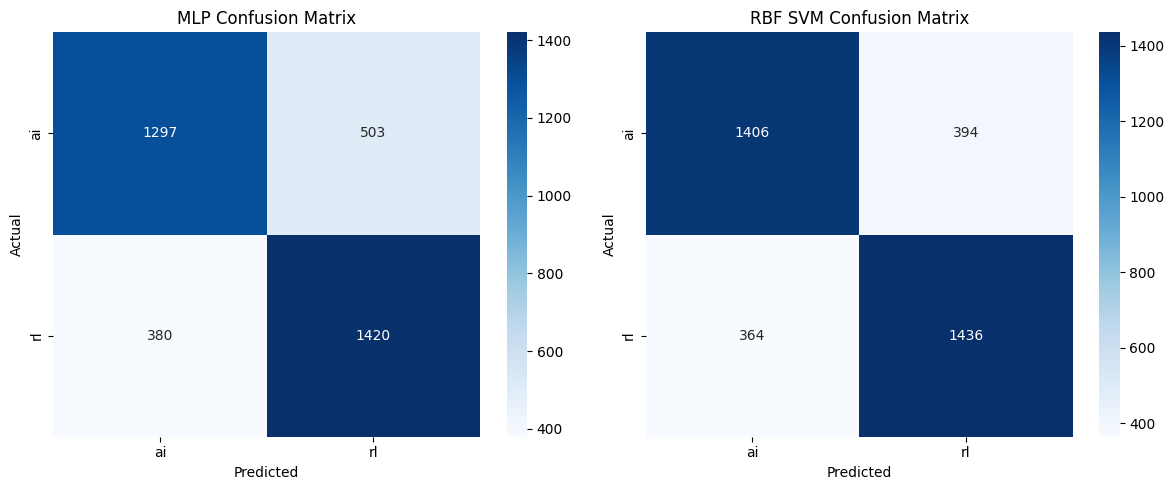


MLP Confusion Matrix (normalized):


,Predicted: ai,Predicted: rl
Actual: ai,0.7206,0.2794
Actual: rl,0.2111,0.7889



RBF SVM Confusion Matrix (normalized):


,Predicted: ai,Predicted: rl
Actual: ai,0.7811,0.2189
Actual: rl,0.2022,0.7978


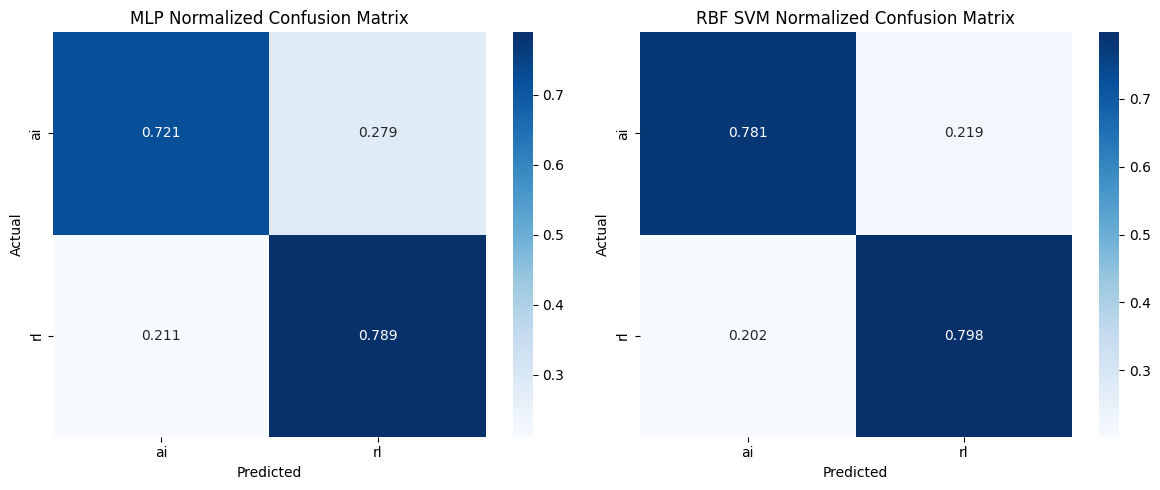

In [10]:
# ============================================================
# Cell 7: Generate and Display Confusion Matrices
# ============================================================

print("Generating confusion matrices...\n")

# ------------------------------------------------------------
# Define class order for confusion matrices
# ------------------------------------------------------------
class_names = [AI_LABEL, REAL_LABEL]
class_order_encoded = label_encoder.transform(class_names)

# ------------------------------------------------------------
# Compute confusion matrices
# ------------------------------------------------------------
cm_mlp = confusion_matrix(y_test, y_pred_mlp, labels=class_order_encoded)
cm_rbf = confusion_matrix(y_test, y_pred_rbf, labels=class_order_encoded)

print("Confusion matrices computed successfully.\n")

# ------------------------------------------------------------
# Display raw confusion matrices as tables
# ------------------------------------------------------------
cm_mlp_df = pd.DataFrame(
    cm_mlp,
    index=[f"Actual: {label}" for label in class_names],
    columns=[f"Predicted: {label}" for label in class_names]
)

cm_rbf_df = pd.DataFrame(
    cm_rbf,
    index=[f"Actual: {label}" for label in class_names],
    columns=[f"Predicted: {label}" for label in class_names]
)

print("MLP Confusion Matrix (counts):")
display(cm_mlp_df)

print("\nRBF SVM Confusion Matrix (counts):")
display(cm_rbf_df)

# ------------------------------------------------------------
# Plot side-by-side confusion matrices (counts)
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_mlp,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)
axes[0].set_title("MLP Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_rbf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)
axes[1].set_title("RBF SVM Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Compute normalized confusion matrices (row-wise)
# ------------------------------------------------------------
cm_mlp_normalized = cm_mlp.astype(float) / cm_mlp.sum(axis=1, keepdims=True)
cm_rbf_normalized = cm_rbf.astype(float) / cm_rbf.sum(axis=1, keepdims=True)

cm_mlp_norm_df = pd.DataFrame(
    cm_mlp_normalized,
    index=[f"Actual: {label}" for label in class_names],
    columns=[f"Predicted: {label}" for label in class_names]
)

cm_rbf_norm_df = pd.DataFrame(
    cm_rbf_normalized,
    index=[f"Actual: {label}" for label in class_names],
    columns=[f"Predicted: {label}" for label in class_names]
)

print("\nMLP Confusion Matrix (normalized):")
display(cm_mlp_norm_df.round(4))

print("\nRBF SVM Confusion Matrix (normalized):")
display(cm_rbf_norm_df.round(4))

# ------------------------------------------------------------
# Plot side-by-side normalized confusion matrices
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(
    cm_mlp_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[0]
)
axes[0].set_title("MLP Normalized Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

sns.heatmap(
    cm_rbf_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    ax=axes[1]
)
axes[1].set_title("RBF SVM Normalized Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()



Generating ROC curves...

ROC curves computed successfully.
Number of MLP ROC points: 1178
Number of RBF SVM ROC points: 1055


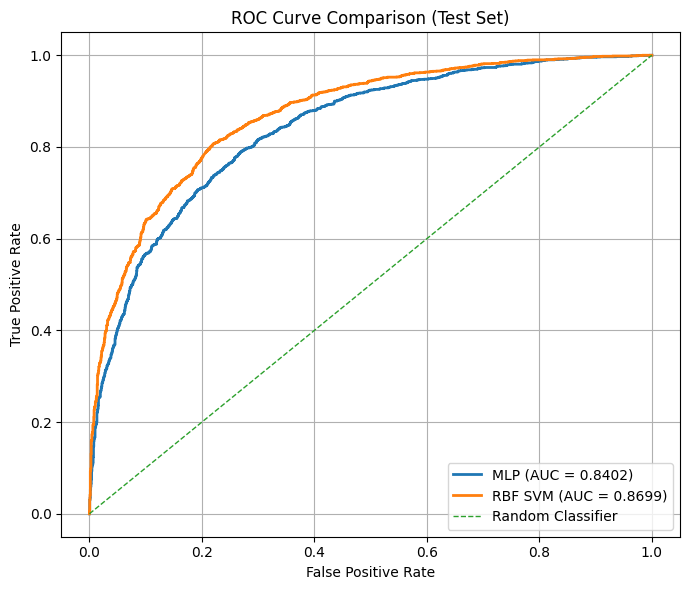


First 10 ROC points (MLP):


,threshold,fpr,tpr
0,inf,0.000000,0.000000
1,1.000000,0.000000,0.000556
2,1.000000,0.000000,0.005556
3,1.000000,0.000556,0.005556
4,0.999994,0.000556,0.030000
5,0.999994,0.001111,0.030000
6,0.999992,0.001111,0.035556
7,0.999992,0.001667,0.035556
8,0.999977,0.001667,0.052778
9,0.999976,0.002222,0.052778



First 10 ROC points (RBF SVM):


,threshold,fpr,tpr
0,inf,0.000000,0.000000
1,0.999995,0.000000,0.000556
2,0.997994,0.000000,0.006111
3,0.997870,0.000556,0.006111
4,0.989550,0.000556,0.030556
5,0.989269,0.001111,0.030556
6,0.985771,0.001111,0.041667
7,0.985731,0.001667,0.041667
8,0.967479,0.001667,0.093333
9,0.967277,0.002222,0.093333


In [11]:
# ============================================================
# Cell 8: Generate and Display ROC Curves
# ============================================================

print("Generating ROC curves...\n")

# ------------------------------------------------------------
# Create binary target with AI as positive class = 1
# ------------------------------------------------------------
y_test_ai_positive = (df_test["class_label"] == AI_LABEL).astype(int).to_numpy()

# ------------------------------------------------------------
# Compute ROC curves
# ------------------------------------------------------------
fpr_mlp, tpr_mlp, thresholds_mlp = roc_curve(y_test_ai_positive, y_score_mlp)
fpr_rbf, tpr_rbf, thresholds_rbf = roc_curve(y_test_ai_positive, y_score_rbf)

print("ROC curves computed successfully.")
print(f"Number of MLP ROC points: {len(fpr_mlp)}")
print(f"Number of RBF SVM ROC points: {len(fpr_rbf)}")

# ------------------------------------------------------------
# Plot ROC curves (comparison)
# ------------------------------------------------------------
plt.figure(figsize=(7, 6))

plt.plot(
    fpr_mlp,
    tpr_mlp,
    linewidth=2,
    label=f"MLP (AUC = {roc_auc_mlp:.4f})"
)

plt.plot(
    fpr_rbf,
    tpr_rbf,
    linewidth=2,
    label=f"RBF SVM (AUC = {roc_auc_rbf:.4f})"
)

# Random classifier baseline
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (Test Set)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# Preview first few ROC points
# ------------------------------------------------------------
roc_preview_mlp = pd.DataFrame({
    "threshold": thresholds_mlp[:10],
    "fpr": fpr_mlp[:10],
    "tpr": tpr_mlp[:10]
})

roc_preview_rbf = pd.DataFrame({
    "threshold": thresholds_rbf[:10],
    "fpr": fpr_rbf[:10],
    "tpr": tpr_rbf[:10]
})

print("\nFirst 10 ROC points (MLP):")
display(roc_preview_mlp.round(6))

print("\nFirst 10 ROC points (RBF SVM):")
display(roc_preview_rbf.round(6))



In [12]:
# ============================================================
# Cell 9: Summarize Final Test Results in Tabular Form
# ============================================================

print("Building final test-results summary tables...\n")

# ------------------------------------------------------------
# Create final results summary table
# ------------------------------------------------------------
df_final_results = pd.DataFrame([
    {
        "model": "MLP",
        "model_file": "final_mlp_model.pkl",
        "accuracy": accuracy_mlp,
        "precision": precision_mlp,
        "recall": recall_mlp,
        "f1_score": f1_mlp,
        "roc_auc": roc_auc_mlp
    },
    {
        "model": "RBF SVM",
        "model_file": "final_rbf_svm_model.pkl",
        "accuracy": accuracy_rbf,
        "precision": precision_rbf,
        "recall": recall_rbf,
        "f1_score": f1_rbf,
        "roc_auc": roc_auc_rbf
    }
])

# ------------------------------------------------------------
# Sort by ROC-AUC
# ------------------------------------------------------------
df_final_results = df_final_results.sort_values(
    by="roc_auc",
    ascending=False
).reset_index(drop=True)

print("Final test-results summary table:\n")
display(df_final_results.round(4))

# ------------------------------------------------------------
# Create report-friendly comparison summary
# ------------------------------------------------------------
df_final_comparison = pd.DataFrame({
    "metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "MLP": [
        accuracy_mlp,
        precision_mlp,
        recall_mlp,
        f1_mlp,
        roc_auc_mlp
    ],
    "RBF SVM": [
        accuracy_rbf,
        precision_rbf,
        recall_rbf,
        f1_rbf,
        roc_auc_rbf
    ]
})

print("\nFinal comparison summary:\n")
display(df_final_comparison.round(4))



Building final test-results summary tables...

Final test-results summary table:



,model,model_file,accuracy,precision,recall,f1_score,roc_auc
0,RBF SVM,final_rbf_svm_model.pkl,0.7894,0.7944,0.7811,0.7877,0.8699
1,MLP,final_mlp_model.pkl,0.7547,0.7734,0.7206,0.7460,0.8402



Final comparison summary:



,metric,MLP,RBF SVM
0,Accuracy,0.7547,0.7894
1,Precision,0.7734,0.7944
2,Recall,0.7206,0.7811
3,F1-score,0.7460,0.7877
4,ROC-AUC,0.8402,0.8699


In [15]:
# ============================================================
# Cell 10: Save Final Evaluation Outputs
# ============================================================

print("Saving final evaluation outputs...\n")

# ------------------------------------------------------------
# Save final metric summary table
# ------------------------------------------------------------
df_final_results.to_csv(FINAL_RESULTS_CSV_PATH, index=False)
print(f"Saved final results CSV: {FINAL_RESULTS_CSV_PATH}")

# ------------------------------------------------------------
# Save final metrics dictionary as JSON
# ------------------------------------------------------------
final_metrics = {
    "MLP": final_metrics_mlp,
    "RBF_SVM": final_metrics_rbf
}

with open(FINAL_RESULTS_JSON_PATH, "w") as f:
    json.dump(final_metrics, f, indent=4)

print(f"Saved final results JSON: {FINAL_RESULTS_JSON_PATH}")

# ------------------------------------------------------------
# Save confusion matrices
# ------------------------------------------------------------
cm_mlp_df.to_csv(CONFUSION_MATRIX_MLP_PATH)
print(f"Saved MLP confusion matrix CSV: {CONFUSION_MATRIX_MLP_PATH}")

cm_rbf_df.to_csv(CONFUSION_MATRIX_RBF_PATH)
print(f"Saved RBF SVM confusion matrix CSV: {CONFUSION_MATRIX_RBF_PATH}")

# ------------------------------------------------------------
# Save ROC curve points
# ------------------------------------------------------------
df_roc_mlp = pd.DataFrame({
    "threshold": thresholds_mlp,
    "fpr": fpr_mlp,
    "tpr": tpr_mlp
})

df_roc_rbf = pd.DataFrame({
    "threshold": thresholds_rbf,
    "fpr": fpr_rbf,
    "tpr": tpr_rbf
})

df_roc_mlp.to_csv(ROC_POINTS_MLP_PATH, index=False)
print(f"Saved MLP ROC curve points CSV: {ROC_POINTS_MLP_PATH}")

df_roc_rbf.to_csv(ROC_POINTS_RBF_PATH, index=False)
print(f"Saved RBF SVM ROC curve points CSV: {ROC_POINTS_RBF_PATH}")

# ------------------------------------------------------------
# Save final comparison summary
# ------------------------------------------------------------
df_final_comparison.to_csv(FINAL_COMPARISON_PATH, index=False)
print(f"Saved final comparison summary CSV: {FINAL_COMPARISON_PATH}")

print("\nAll final evaluation outputs saved successfully.")



Saving final evaluation outputs...

Saved final results CSV: /content/dip-ai-image-detection/metadata/results/final_test_results.csv
Saved final results JSON: /content/dip-ai-image-detection/metadata/results/final_test_results.json
Saved MLP confusion matrix CSV: /content/dip-ai-image-detection/metadata/results/final_confusion_matrix_mlp.csv
Saved RBF SVM confusion matrix CSV: /content/dip-ai-image-detection/metadata/results/final_confusion_matrix_rbf_svm.csv
Saved MLP ROC curve points CSV: /content/dip-ai-image-detection/metadata/results/final_roc_points_mlp.csv
Saved RBF SVM ROC curve points CSV: /content/dip-ai-image-detection/metadata/results/final_roc_points_rbf_svm.csv
Saved final comparison summary CSV: /content/dip-ai-image-detection/metadata/results/final_comparison_summary.csv

All final evaluation outputs saved successfully.
